Data loaded successfully.


C:\Users\saipr\AppData\Local\Temp\ipykernel_12572\2726868735.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lab_counts.values, y=lab_counts.index, palette='viridis')


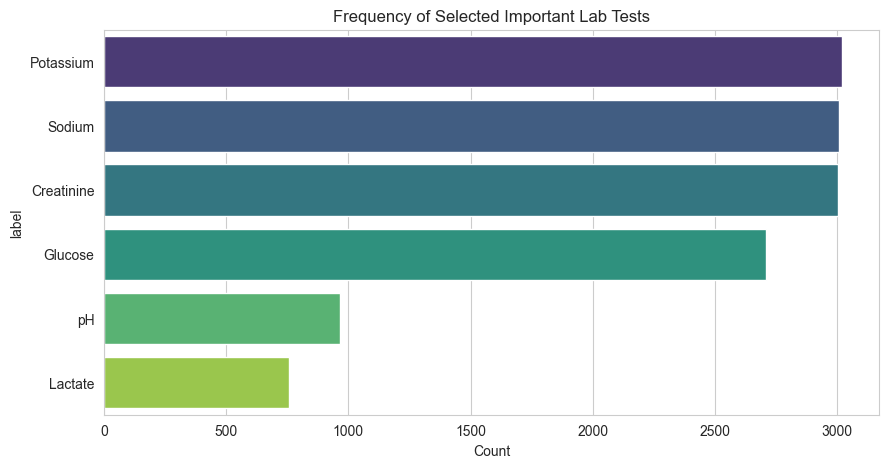

Processing Complete. File saved to: C:\AINutriCare\Data\Transformed\processed_mimic_24h_combined.csv
      hadm_id  hour_bin  Creatinine     Glucose  Lactate  Potassium  \
0  20044587.0         0    1.504829  147.330645      1.4   4.131132   
1  20044587.0         1    1.504829  147.330645      2.7   4.131132   
2  20044587.0         2    1.504829  147.330645      1.8   4.131132   
3  20044587.0         3    1.504829  147.330645      1.8   4.131132   
4  20044587.0         4    1.504829  147.330645      2.7   4.131132   

       Sodium    pH  HeartRate  
0  137.384556  7.37  87.433344  
1  137.384556  7.40  87.433344  
2  137.384556  7.45  87.433344  
3  137.384556  7.45  87.433344  
4  137.384556  7.34  87.433344  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Path Configuration
raw_dir = r"C:\AINutriCare\Data\Raw"
output_dir = r"C:\AINutriCare\Data\Transformed"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

IMPORTANT_LAB_IDS = [50931, 50813, 50912, 50971, 50983, 50820]
IMPORTANT_VITAL_IDS = [211, 220045, 456, 52, 220052]

def get_raw_path(filename):
    return os.path.join(raw_dir, filename)

try:
    labevents = pd.read_csv(get_raw_path('labevents.csv'), parse_dates=['charttime'])
    admissions = pd.read_csv(get_raw_path('admissions.csv'), parse_dates=['admittime'])
    d_labitems = pd.read_csv(get_raw_path('d_labitems.csv'))
    chartevents = pd.read_csv(get_raw_path('chartevents.csv'), parse_dates=['charttime'])
    
    lab_item_map = d_labitems.set_index('itemid')['label'].to_dict()
    print("Data loaded successfully.")

    if not labevents.empty:
        # --- Process Labs ---
        lab_subset = labevents[labevents['itemid'].isin(IMPORTANT_LAB_IDS)].copy()
        lab_subset['label'] = lab_subset['itemid'].map(lab_item_map)

        # EDA Plot
        lab_counts = lab_subset['label'].value_counts()
        plt.figure(figsize=(10, 5))
        sns.barplot(x=lab_counts.values, y=lab_counts.index, palette='viridis')
        plt.title('Frequency of Selected Important Lab Tests')
        plt.xlabel('Count')
        plt.show()

        # Time Series Extraction
        lab_merged = pd.merge(lab_subset, admissions[['hadm_id', 'admittime']], on='hadm_id', how='inner')
        lab_merged['hours_in'] = (lab_merged['charttime'] - lab_merged['admittime']).dt.total_seconds() / 3600
        lab_24h = lab_merged[(lab_merged['hours_in'] >= 0) & (lab_merged['hours_in'] <= 24)].copy()
        lab_24h['hour_bin'] = np.floor(lab_24h['hours_in']).astype(int)

        # Pivot and Reindex Labs
        lab_pivot = lab_24h.pivot_table(index=['hadm_id', 'hour_bin'], columns='label', values='valuenum', aggfunc='mean')
        unique_stays = lab_pivot.index.get_level_values(0).unique()
        full_idx = pd.MultiIndex.from_product([unique_stays, range(24)], names=['hadm_id', 'hour_bin'])
        
        lab_hourly = lab_pivot.reindex(full_idx)
        lab_hourly = lab_hourly.groupby('hadm_id').ffill()
        lab_hourly = lab_hourly.fillna(lab_hourly.mean())

        # --- Process Vitals ---
        vitals_subset = chartevents[chartevents['itemid'].isin(IMPORTANT_VITAL_IDS)].copy()
        vitals_merged = pd.merge(vitals_subset, admissions[['hadm_id', 'admittime']], on='hadm_id', how='inner')
        vitals_merged['hours_in'] = (vitals_merged['charttime'] - vitals_merged['admittime']).dt.total_seconds() / 3600
        vitals_24h = vitals_merged[(vitals_merged['hours_in'] >= 0) & (vitals_merged['hours_in'] <= 24)].copy()
        vitals_24h['hour_bin'] = np.floor(vitals_24h['hours_in']).astype(int)

        vitals_pivot = vitals_24h.pivot_table(index=['hadm_id', 'hour_bin'], values='valuenum', aggfunc='mean').rename(columns={'valuenum': 'HeartRate'})
        vitals_hourly = vitals_pivot.reindex(full_idx)
        vitals_hourly = vitals_hourly.groupby('hadm_id').ffill().fillna(vitals_hourly.mean())

        # --- Combine and Save ---
        combined_df = pd.concat([lab_hourly, vitals_hourly], axis=1)
        output_path = os.path.join(output_dir, 'processed_mimic_24h_combined.csv')
        combined_df.reset_index(inplace=True)
        combined_df.to_csv(output_path, index=False)
        
        print(f"Processing Complete. File saved to: {output_path}")
        print(combined_df.head())

except FileNotFoundError as e:
    print(f"Error: File not found. Check your path: {e.filename}")